# Tutorial: Protein Engineering with SeqOpt

**Protein engineering vs. de novo protein design** are two distinct paradigms. *De novo design* builds **new proteins from the ground up** rather than repurposing an existing one, typically via a structure-first pipeline — [RFdiffusion](https://doi.org/10.1038/s41586-023-06415-8) (backbone) → [ProteinMPNN](https://doi.org/10.1126/science.add2187) (sequence) → [AlphaFold](https://doi.org/10.1038/s41586-021-03819-2) (validation) ([Yang et al., 2026](https://doi.org/10.1038/s41586-026-10328-7)). *Protein engineering* instead **optimizes an existing protein** by iterative mutation and selection (directed evolution); the **machine-learning-guided** flavour learns a fitness model to prioritize which variants to make ([Yang et al., 2019](https://doi.org/10.1038/s41592-019-0496-6); [Wittmann et al., 2021](https://doi.org/10.1016/j.sbi.2021.01.008)).

`SeqOpt` (**pro**) is that ML-guided directed evolution as a **multi-objective** search: it mutates one wild-type and returns the **Pareto front** of variants (NSGA-II; a model-bound `SeqMut` is the fitness engine), read with `SeqOptPlot`. Here we **engineer** a "super substrate" for gamma-secretase (GSEC): take a non-substrate transmembrane domain and mutate it to maximize the predicted substrate probability with as few mutations as possible.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import aaanalysis as aa
aa.options["verbose"] = False
aa.plot_settings()

## 1. Data and a substrate classifier

Load the gamma-secretase dataset and the bundled interpretable **CPP feature set**, build the feature matrix, and train a simple RandomForest substrate classifier.

In [2]:
df_feat = aa.load_features(name="DOM_GSEC")
df_seq  = aa.load_dataset(name="DOM_GSEC", n=50)
labels  = df_seq["label"].to_list()        # 1 = GSEC substrate
aa.display_df(df_seq, n_rows=5, show_shape=True)

DataFrame shape: (100, 8)


,entry,sequence,label,tmd_start,tmd_stop,jmd_n,tmd,jmd_c
1,Q14802,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,0,37,59,NSPFYYDWHS,LQVGGLICAGVLCAMGIIIVMSA,KCKCKFGQKS
2,Q86UE4,MAARSWQDELAQQAE...SPKQIKKKKKARRET,0,50,72,LGLEPKRYPG,WVILVGTGALGLLLLFLLGYGWA,AACAGARKKR
3,Q969W9,MHRLMGVNSTAAAAA...AIWSKEKDKQKGHPL,0,41,63,FQSMEITELE,FVQIIIIVVVMMVMVVVITCLLS,HYKLSARSFI
4,P53801,MAPGVARGPTPYWRL...GLFKEENPYARFENN,0,97,119,RWGVCWVNFE,ALIITMSVVGGTLLLGIAICCCC,CCRRKRSRKP
5,Q8IUW5,MAPRALPGSAVLAAA...EVPATPVKRERSGTE,0,59,81,NDTGNGHPEY,IAYALVPVFFIMGLFGVLICHLL,KKKGYRCTTE


In [3]:
sf = aa.SequenceFeature()
X = np.asarray(sf.feature_matrix(features=df_feat["feature"],
                                 df_parts=sf.get_df_parts(df_seq=df_seq),
                                 df_scales=aa.load_scales()), dtype=float)
model = RandomForestClassifier(n_estimators=100, random_state=0).fit(X, labels)
print("training accuracy:", round(model.score(X, labels), 3))

training accuracy: 1.0


/Users/stephanbreimann/Programming/1Packages/wt-seqopt-deap/aaanalysis/feature_engineering/_backend/cpp_run.py:163: UserWarning: CPP is using the Python kernel fallback — the compiled Cython extension is not available in this install. Output is bit-exact with the Cython path but ~2x slower. Reinstall via `pip install --force-reinstall aaanalysis` to fetch a prebuilt wheel.
  warnings.warn(


## 2. The design task

Pick a **non-substrate** as the wild-type. Two objectives: maximize the predicted substrate probability shift (`delta_pred`) and minimize the number of mutations (`n_mut`).

In [4]:
wt = df_seq[df_seq["label"] == 0].iloc[[0]].reset_index(drop=True)
p_wt = model.predict_proba(X[df_seq["label"].values == 0][:1])[0, 1]
print("wild-type:", wt["entry"].iloc[0], "| P(substrate) =", round(float(p_wt), 3))
objectives = [("substrate", "max", "delta_pred"), ("parsimony", "min", "n_mut")]

wild-type: Q14802 | P(substrate) = 0.11


## 3. Run the optimizer

`mode="importance"` guides mutations by the static feature importance (fast, deterministic); `run` returns the Pareto front `df_pareto` (objective columns + non-dominated `rank` + `crowding`).

In [5]:
seqopt = aa.SeqOpt(mode="importance", model=model, target_class=1, random_state=42)
df_pareto = seqopt.run(df_seq=wt, df_feat=df_feat, objectives=objectives,
                       pop_size=40, n_gen=25, n_mut_max=6, region="tmd")
aa.display_df(df_pareto, n_rows=10, show_shape=True)

DataFrame shape: (7, 8)


,entry,variant,n_mut,sequence_mut,substrate,parsimony,rank,crowding
1,Q14802,,0,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,0.000000,0.000000,0,inf
2,Q14802,C49V+I54C+I55R+S58R,4,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,28.000000,4.000000,0,inf
3,Q14802,S58R,1,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,14.000000,1.000000,0,0.696429
4,Q14802,C49M+S58R,2,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,25.000000,2.000000,0,0.482143
5,Q14802,C49V+I55R+S58R,3,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,27.000000,3.000000,0,0.160714
6,Q14802,Q38W+C49M+S58R,3,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,27.000000,3.000000,0,0.142857
7,Q14802,C49L+I55R+S58R,3,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,27.000000,3.000000,0,0.000000


In [6]:
df_eval = seqopt.eval(df_pareto=df_pareto)
aa.display_df(df_eval, n_rows=10, show_shape=True)

DataFrame shape: (1, 3)


,hypervolume,n_front,spread
1,66.000000,7,0.577352


## 4. Read the trade-off front

Each `rank=0` variant is a non-dominated trade-off between substrate gain and mutation count.

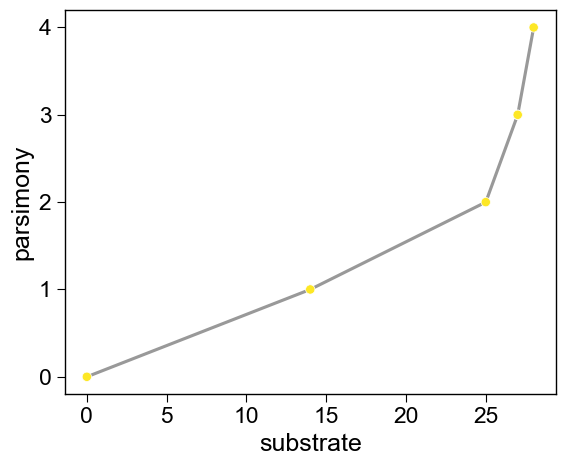

In [7]:
aa.SeqOptPlot().pareto_front(df_pareto=df_pareto, x="substrate", y="parsimony")
plt.tight_layout(); plt.show()

## 5. Did it converge?

The convergence panels show the dominated hypervolume rising, the front spread, and each objective's best/mean band across generations.

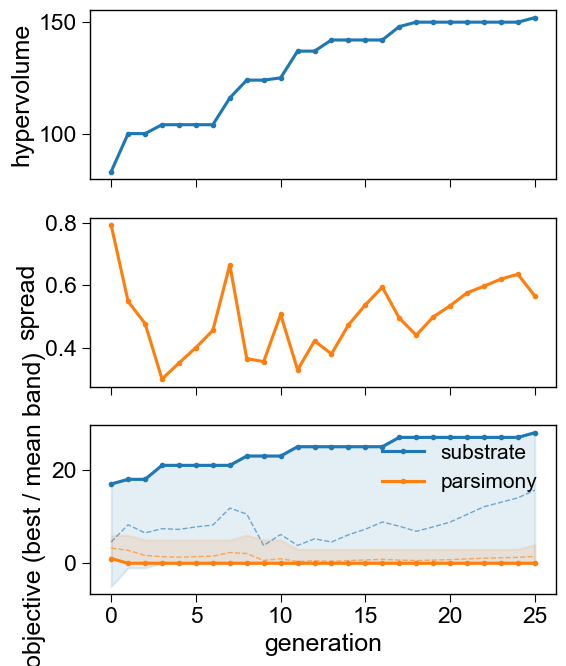

In [8]:
aa.SeqOptPlot().convergence(history=seqopt.history_)
plt.tight_layout(); plt.show()

## 6. Which mutations won, and how were they built up?

The **mutation map** shows substitution enrichment across the front (position x amino acid); the **genealogy** shows the mutational lineage from wild-type to the designed variants.

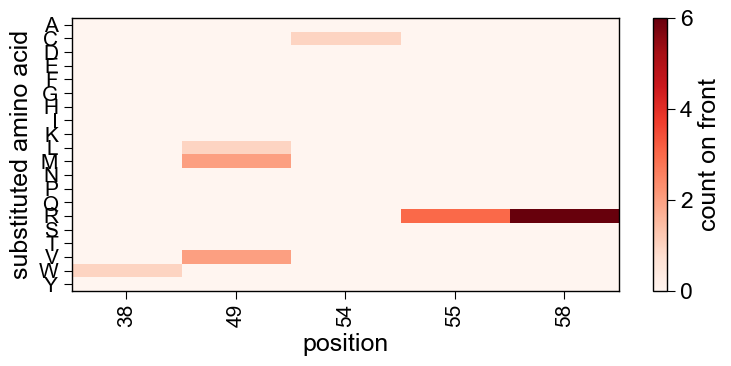

In [9]:
aa.SeqOptPlot().mutation_map(df_pareto=df_pareto)
plt.tight_layout(); plt.show()

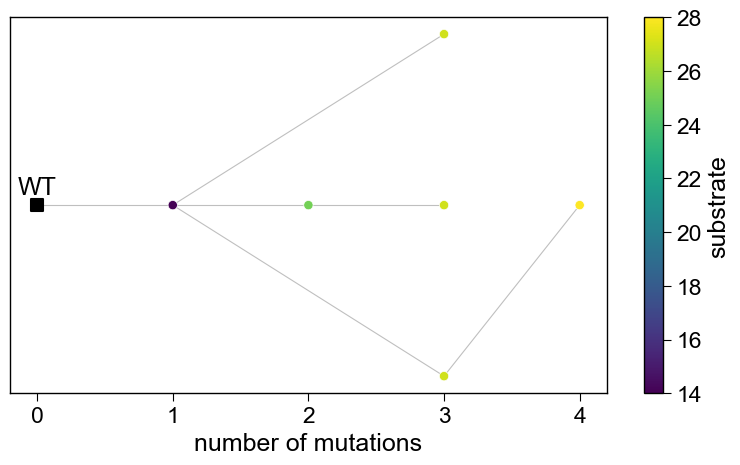

In [10]:
aa.SeqOptPlot().genealogy(df_pareto=df_pareto, front_only=False)
plt.tight_layout(); plt.show()

## 7. More objectives

Add a third objective — keep the feature profile close to natural (`delta_cpp`) — and read it with a 3-D front and parallel coordinates. Objectives can also be **any** `callable(sequence) -> float` (a scikit/torch model, or a sequence-level tool / web API).

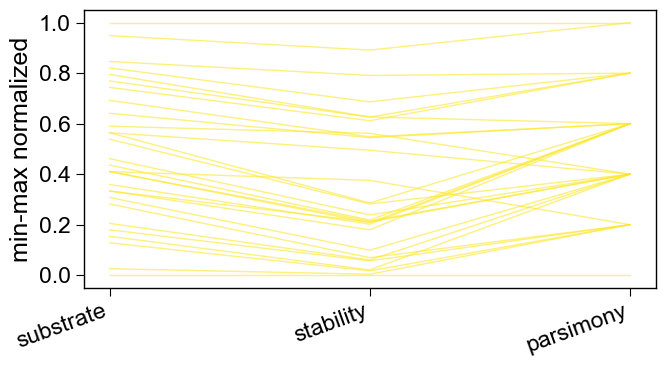

In [11]:
objectives3 = [("substrate", "max", "delta_pred"),
               ("stability", "min", "delta_cpp"),
               ("parsimony", "min", "n_mut")]
df3 = seqopt.run(df_seq=wt, df_feat=df_feat, objectives=objectives3,
                 pop_size=40, n_gen=25, n_mut_max=6, region="tmd")
aa.SeqOptPlot().parallel_coordinates(df_pareto=df3,
    objectives=["substrate", "stability", "parsimony"])
plt.tight_layout(); plt.show()

## 8. SHAP-guided design

The headline `mode="impact"` refits a `ShapModel` every generation (fuzzy labeling) to mutate the residues SHAP deems most important — pass the labeled reference set.

In [12]:
df_shap = aa.SeqOpt(mode="impact", model=model, target_class=1, df_seq_ref=df_seq,
                    labels=labels, random_state=0).run(
    df_seq=wt, df_feat=df_feat, objectives=objectives, pop_size=12, n_gen=4,
    n_mut_max=4, region="tmd")
aa.display_df(df_shap, n_rows=10, show_shape=True)

DataFrame shape: (9, 8)


,entry,variant,n_mut,sequence_mut,substrate,parsimony,rank,crowding
1,Q14802,,0,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,0.000000,0.000000,0,inf
2,Q14802,C49E+S58R,2,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,21.000000,2.000000,0,inf
3,Q14802,S58F,1,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,8.000000,1.000000,0,0.559524
4,Q14802,V56M,1,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,8.000000,1.000000,0,0.440476
5,Q14802,C49E,1,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,8.000000,1.000000,0,0.000000
6,Q14802,C49E+S58R+A59W,3,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,20.000000,3.000000,1,inf
7,Q14802,A50G,1,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,0.000000,1.000000,1,inf
8,Q14802,A50G+S58R,2,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,14.000000,2.000000,1,1.000000
9,Q14802,C49Y+A50G+S58R+A59W,4,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,20.000000,4.000000,2,inf


## Summary

`SeqOpt` turned a non-substrate into predicted GSEC substrates along a Pareto front of substrate-gain vs. mutation-count, and `SeqOptPlot` exposed the trade-offs, convergence, the enriched mutations and their lineage. The evolutionary machinery is a pure-Python re-implementation of NSGA-II (DEAP-equivalent); the design signal comes from your model — any `predict_proba` classifier or `callable(sequence)` predictor.